In [1]:
# ============================================================
# FULL MATCHED-ABLATION COMPARISON USING BD-CODE DATA CONVENTION
#
# This script keeps the full matched-ablation model list:
#   1. Persistence
#   2. Direct ridge
#   3. Matched ESN
#   4. Random linear features
#   5. Random nonlinear features
#   6. Single Lorenz
#   7. Low-rho non-chaotic Lorenz
#   8. Homogeneous chaotic Lorenz
#   9. DynML heterogeneous Lorenz
#
# But uses the same data/metric convention as the fixed-N BD code:
#   - first 8000 samples
#   - global input/output standardization before split
#   - 30 shuffled random seeds
#   - metrics computed directly in standardized output space
#   - no inverse-transform before computing metrics
#
# Output:
#   rossler_matched_ablation_BD_style_by_seed.csv
#   rossler_matched_ablation_BD_style_summary.csv
#   rossler_matched_ablation_BD_style_table.csv
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from pathlib import Path
from scipy.integrate import solve_ivp
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ============================================================
# CONFIGURATION
# ============================================================

INPUT_CSV = Path("input_data_rossler.csv")
OUTPUT_CSV = Path("output_data_rossler.csv")
DATASET_NAME = "Rössler"

NUM_SAMPLES_TO_USE = 8000

N_FIXED = 150
FEATURE_DIM = 3 * N_FIXED

PREDICTION_NUM_RANDOM_SEEDS = 10
TEST_FRACTION = 0.20

RIDGE_ALPHA_READOUT = 1e-6
RIDGE_ALPHA_BASELINE = 1.0

R_LOW, R_HIGH = 1.0, 30.0

T_INITIAL = 0.0
T_FINAL = 1.0
NUM_EVAL_POINTS = 500

RANDOM_FEATURE_SCALE = 1.0

ESN_SPECTRAL_RADIUS = 0.90
ESN_INPUT_SCALE = 0.50
ESN_LEAK_RATE = 1.00
ESN_SPARSITY = 0.10

OUTPUT_BY_SEED = "rossler_matched_ablation_BD_style_by_seed.csv"
OUTPUT_SUMMARY = "rossler_matched_ablation_BD_style_summary.csv"
OUTPUT_TABLE = "rossler_matched_ablation_BD_style_table.csv"


# ============================================================
# LOAD DATA USING BD-CODE STYLE
# ============================================================

if not INPUT_CSV.exists():
    raise FileNotFoundError(f"Could not find {INPUT_CSV}")

if not OUTPUT_CSV.exists():
    raise FileNotFoundError(f"Could not find {OUTPUT_CSV}")

input_data = pd.read_csv(INPUT_CSV).iloc[:, 1:NUM_SAMPLES_TO_USE + 1].values
output_data = pd.read_csv(OUTPUT_CSV).iloc[:, 1:NUM_SAMPLES_TO_USE + 1].values

D = input_data.shape[1]
M = input_data.shape[0]
P = output_data.shape[0]

print("Loaded data")
print("-----------")
print("Dataset:", DATASET_NAME)
print("Input shape:", input_data.shape)
print("Output shape:", output_data.shape)
print("Samples D:", D)
print("Input features M:", M)
print("Output features P:", P)
print("N fixed:", N_FIXED)
print("Matched feature dimension:", FEATURE_DIM)

if input_data.shape[1] != output_data.shape[1]:
    raise ValueError("Input and output have different numbers of samples.")

if not np.all(np.isfinite(input_data)):
    raise ValueError("Input data contain NaN or infinite values.")

if not np.all(np.isfinite(output_data)):
    raise ValueError("Output data contain NaN or infinite values.")


# ============================================================
# GLOBAL STANDARDIZATION BEFORE SPLIT, SAME AS BD CODE
# ============================================================

scaler_input = StandardScaler()
input_data_norm = scaler_input.fit_transform(input_data.T).T

scaler_output = StandardScaler()
output_data_norm = scaler_output.fit_transform(output_data.T).T

print()
print("Standardized data")
print("-----------------")
print("input_data_norm shape:", input_data_norm.shape)
print("output_data_norm shape:", output_data_norm.shape)


# ============================================================
# METRICS IN STANDARDIZED OUTPUT SPACE
# ============================================================

def compute_regression_metrics(y_true, y_pred):
    """
    Compute metrics in the same standardized space.

    y_true, y_pred shape:
        num_outputs x num_samples
    """

    yt = np.asarray(y_true).reshape(-1)
    yp = np.asarray(y_pred).reshape(-1)

    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)

    if np.std(yt) > 0 and np.std(yp) > 0:
        pearson_r, pearson_p = pearsonr(yt, yp)
    else:
        pearson_r, pearson_p = np.nan, np.nan

    if np.std(yt) > 0:
        calibration_slope, calibration_intercept = np.polyfit(yt, yp, 1)
    else:
        calibration_slope, calibration_intercept = np.nan, np.nan

    return {
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "calibration_slope": calibration_slope,
        "calibration_intercept": calibration_intercept
    }


def summarize_metrics(metrics_df):
    metric_cols = [
        "pearson_r",
        "rmse",
        "mae",
        "r2",
        "calibration_slope",
        "calibration_intercept"
    ]

    rows = []

    grouped = metrics_df.groupby(
        ["dataset", "model", "split", "feature_dim"],
        dropna=False
    )

    for keys, group in grouped:
        dataset, model, split, feature_dim = keys

        row = {
            "dataset": dataset,
            "model": model,
            "split": split,
            "feature_dim": feature_dim,
            "n_seeds": group["seed_id"].nunique()
        }

        for metric in metric_cols:
            values = group[metric].dropna().values
            n = len(values)

            mean = np.mean(values) if n > 0 else np.nan
            sd = np.std(values, ddof=1) if n > 1 else np.nan
            sem = sd / np.sqrt(n) if n > 1 else np.nan
            ci95 = 1.96 * sem if n > 1 else np.nan

            row[f"{metric}_mean"] = mean
            row[f"{metric}_sd"] = sd
            row[f"{metric}_ci95"] = ci95

        rows.append(row)

    return pd.DataFrame(rows)


def format_mean_ci(mean, ci):
    if pd.isna(mean):
        return "NA"
    if pd.isna(ci):
        return f"{mean:.4f}"
    return f"{mean:.4f} ± {ci:.4f}"


# ============================================================
# LORENZ SYSTEM
# Parameter order:
#   sigma, beta, rho, tau
# ============================================================

def lorenz_system(t, X, params):
    X = X.reshape(len(params), 3)

    sigma = params[:, 0]
    beta = params[:, 1]
    rho = params[:, 2]
    tau = params[:, 3]

    dxdt = (1.0 / tau) * sigma * (X[:, 1] - X[:, 0])
    dydt = (1.0 / tau) * (X[:, 0] * (rho - X[:, 2]) - X[:, 1])
    dzdt = (1.0 / tau) * (X[:, 0] * X[:, 1] - beta * X[:, 2])

    return np.stack([dxdt, dydt, dzdt], axis=1).flatten()


# ============================================================
# LORENZ PARAMETER MODES FOR MATCHED ABLATION
# ============================================================

def build_lorenz_params(mode, n_reservoirs, seed):
    rng = np.random.default_rng(seed)

    if mode == "single_lorenz":
        params = np.array([
            [
                10.0,        # sigma
                8.0 / 3.0,   # beta
                28.0,        # rho
                1.0          # tau
            ]
        ])

    elif mode == "low_rho_nonchaotic":
        params = np.tile(
            [
                10.0,        # sigma
                8.0 / 3.0,   # beta
                10.0,        # rho
                1.0          # tau
            ],
            (n_reservoirs, 1)
        )

    elif mode == "homogeneous_chaotic":
        params = np.tile(
            [
                10.0,        # sigma
                8.0 / 3.0,   # beta
                28.0,        # rho
                1.0          # tau
            ],
            (n_reservoirs, 1)
        )

    elif mode == "heterogeneous_chaotic":
        params = np.array([
            [
                rng.uniform(9.9, 10.1),     # sigma
                rng.uniform(2.65, 2.70),    # beta
                rng.uniform(27.9, 28.1),    # rho
                rng.uniform(1.0, 10.0)      # tau
            ]
            for _ in range(n_reservoirs)
        ])

    else:
        raise ValueError(f"Unknown Lorenz mode: {mode}")

    return params


# ============================================================
# LORENZ FEATURE GENERATION
# ============================================================

def compute_lorenz_features(X_norm, seed, mode, n_reservoirs):
    """
    Generate final Lorenz reservoir states.

    X_norm shape:
        input_dim x num_samples

    returns:
        feature_dim x num_samples
    """

    rng = np.random.default_rng(seed)

    M_local = X_norm.shape[0]
    D_local = X_norm.shape[1]

    reservoir_params = build_lorenz_params(
        mode=mode,
        n_reservoirs=n_reservoirs,
        seed=seed
    )

    R = rng.uniform(R_LOW, R_HIGH, size=(3 * n_reservoirs, M_local))

    t_eval = np.linspace(T_INITIAL, T_FINAL, NUM_EVAL_POINTS)
    features = np.zeros((3 * n_reservoirs, D_local))

    for j in range(D_local):
        if j % 1000 == 0:
            print(f"    Lorenz feature sample {j + 1}/{D_local}")

        x0 = R @ X_norm[:, j]

        sol = solve_ivp(
            lorenz_system,
            (T_INITIAL, T_FINAL),
            x0,
            t_eval=t_eval,
            args=(reservoir_params,),
            method="RK45",
            rtol=1e-6,
            atol=1e-9
        )

        if not sol.success:
            raise RuntimeError(
                f"ODE integration failed for sample {j}, mode={mode}: {sol.message}"
            )

        features[:, j] = sol.y[:, -1]

    return features


# ============================================================
# RANDOM FEATURE BASELINES
# ============================================================

def compute_random_linear_features(X_norm, seed, feature_dim):
    rng = np.random.default_rng(seed)
    M_local = X_norm.shape[0]

    R = rng.normal(
        loc=0.0,
        scale=RANDOM_FEATURE_SCALE / np.sqrt(M_local),
        size=(feature_dim, M_local)
    )

    return R @ X_norm


def compute_random_nonlinear_features(X_norm, seed, feature_dim):
    rng = np.random.default_rng(seed)
    M_local = X_norm.shape[0]

    R = rng.normal(
        loc=0.0,
        scale=RANDOM_FEATURE_SCALE / np.sqrt(M_local),
        size=(feature_dim, M_local)
    )

    b = rng.uniform(-1.0, 1.0, size=(feature_dim, 1))

    return np.tanh(R @ X_norm + b)


# ============================================================
# MATCHED ESN BASELINE
# ============================================================

def rescale_spectral_radius(W, target_radius):
    eigvals = np.linalg.eigvals(W)
    radius = np.max(np.abs(eigvals))

    if radius == 0 or not np.isfinite(radius):
        return W

    return W * (target_radius / radius)


def compute_esn_features(X_norm, seed, n_units):
    """
    Matched ESN baseline for direct-transition targets.

    Each input vector is treated as a one-step driven input.
    The final ESN state is used as the feature representation.
    """

    rng = np.random.default_rng(seed)

    M_local = X_norm.shape[0]
    D_local = X_norm.shape[1]

    W = rng.uniform(-1.0, 1.0, size=(n_units, n_units))
    mask = rng.uniform(0.0, 1.0, size=(n_units, n_units)) < ESN_SPARSITY
    W = W * mask
    W = rescale_spectral_radius(W, ESN_SPECTRAL_RADIUS)

    Win = rng.uniform(
        -ESN_INPUT_SCALE,
        ESN_INPUT_SCALE,
        size=(n_units, M_local)
    )

    features = np.zeros((n_units, D_local))

    for j in range(D_local):
        u = X_norm[:, j]
        x_state = np.zeros(n_units)

        pre_activation = W @ x_state + Win @ u
        x_new = np.tanh(pre_activation)
        x_state = (1.0 - ESN_LEAK_RATE) * x_state + ESN_LEAK_RATE * x_new

        features[:, j] = x_state

    return features


# ============================================================
# READOUT EVALUATION IN BD STANDARDIZED SPACE
# ============================================================

def fit_ridge_readout(X_train_features, Y_train, alpha):
    model = Ridge(alpha=alpha, fit_intercept=True)
    model.fit(X_train_features.T, Y_train.T)
    return model


def evaluate_feature_model(
    model_name,
    feature_dim,
    features,
    train_indices,
    test_indices,
    Y_train,
    Y_test,
    alpha
):
    X_train_features = features[:, train_indices]
    X_test_features = features[:, test_indices]

    model = fit_ridge_readout(
        X_train_features=X_train_features,
        Y_train=Y_train,
        alpha=alpha
    )

    pred_train = model.predict(X_train_features.T).T
    pred_test = model.predict(X_test_features.T).T

    train_metrics = compute_regression_metrics(Y_train, pred_train)
    test_metrics = compute_regression_metrics(Y_test, pred_test)

    rows = [
        {
            "dataset": DATASET_NAME,
            "model": model_name,
            "feature_dim": feature_dim,
            "split": "train",
            **train_metrics
        },
        {
            "dataset": DATASET_NAME,
            "model": model_name,
            "feature_dim": feature_dim,
            "split": "test",
            **test_metrics
        }
    ]

    return rows, pred_train, pred_test


# ============================================================
# MAIN EVALUATION LOOP
# ============================================================

all_seed_metrics = []

start_time = time.time()

for seed_id in range(PREDICTION_NUM_RANDOM_SEEDS):

    print("\n" + "=" * 90)
    print(f"Prediction seed {seed_id + 1}/{PREDICTION_NUM_RANDOM_SEEDS}")
    print("=" * 90)

    rng = np.random.default_rng(2000 + seed_id)

    all_indices = np.arange(D)
    rng.shuffle(all_indices)

    n_test = int(TEST_FRACTION * D)
    test_indices = all_indices[:n_test]
    train_indices = all_indices[n_test:]

    X_train_input = input_data_norm[:, train_indices]
    X_test_input = input_data_norm[:, test_indices]

    Y_train = output_data_norm[:, train_indices]
    Y_test = output_data_norm[:, test_indices]

    X_all_norm = input_data_norm

    seed_predictions = {}

    # ------------------------------------------------------------
    # 1. Persistence baseline
    # ------------------------------------------------------------

    if M == P:
        Y_pred_persistence_train = X_train_input.copy()
        Y_pred_persistence_test = X_test_input.copy()

        train_metrics = compute_regression_metrics(Y_train, Y_pred_persistence_train)
        test_metrics = compute_regression_metrics(Y_test, Y_pred_persistence_test)

        for split_name, metrics in [
            ("train", train_metrics),
            ("test", test_metrics)
        ]:
            all_seed_metrics.append({
                "dataset": DATASET_NAME,
                "seed_id": seed_id,
                "model": "Persistence",
                "feature_dim": M,
                "split": split_name,
                **metrics
            })

        seed_predictions["Persistence"] = (
            Y_pred_persistence_train,
            Y_pred_persistence_test
        )

    # ------------------------------------------------------------
    # 2. Direct ridge baseline
    # ------------------------------------------------------------

    ridge_baseline = Ridge(alpha=RIDGE_ALPHA_BASELINE, fit_intercept=True)
    ridge_baseline.fit(X_train_input.T, Y_train.T)

    Y_pred_ridge_train = ridge_baseline.predict(X_train_input.T).T
    Y_pred_ridge_test = ridge_baseline.predict(X_test_input.T).T

    train_metrics = compute_regression_metrics(Y_train, Y_pred_ridge_train)
    test_metrics = compute_regression_metrics(Y_test, Y_pred_ridge_test)

    for split_name, metrics in [
        ("train", train_metrics),
        ("test", test_metrics)
    ]:
        all_seed_metrics.append({
            "dataset": DATASET_NAME,
            "seed_id": seed_id,
            "model": "Direct ridge",
            "feature_dim": M,
            "split": split_name,
            **metrics
        })

    seed_predictions["Direct ridge"] = (
        Y_pred_ridge_train,
        Y_pred_ridge_test
    )

    # ------------------------------------------------------------
    # 3. Matched ESN
    # ------------------------------------------------------------

    print("Generating matched ESN features")

    phi_esn = compute_esn_features(
        X_norm=X_all_norm,
        seed=2000 + seed_id,
        n_units=FEATURE_DIM
    )

    rows, esn_train, esn_test = evaluate_feature_model(
        model_name="Matched ESN",
        feature_dim=FEATURE_DIM,
        features=phi_esn,
        train_indices=train_indices,
        test_indices=test_indices,
        Y_train=Y_train,
        Y_test=Y_test,
        alpha=RIDGE_ALPHA_READOUT
    )

    for row in rows:
        row["seed_id"] = seed_id
        all_seed_metrics.append(row)

    seed_predictions["Matched ESN"] = (esn_train, esn_test)

    # ------------------------------------------------------------
    # 4. Random linear features
    # ------------------------------------------------------------

    print("Generating random linear features")

    phi_random_linear = compute_random_linear_features(
        X_norm=X_all_norm,
        seed=2000 + seed_id,
        feature_dim=FEATURE_DIM
    )

    rows, random_linear_train, random_linear_test = evaluate_feature_model(
        model_name="Random linear features",
        feature_dim=FEATURE_DIM,
        features=phi_random_linear,
        train_indices=train_indices,
        test_indices=test_indices,
        Y_train=Y_train,
        Y_test=Y_test,
        alpha=RIDGE_ALPHA_READOUT
    )

    for row in rows:
        row["seed_id"] = seed_id
        all_seed_metrics.append(row)

    seed_predictions["Random linear features"] = (
        random_linear_train,
        random_linear_test
    )

    # ------------------------------------------------------------
    # 5. Random nonlinear features
    # ------------------------------------------------------------

    print("Generating random nonlinear features")

    phi_random_nonlinear = compute_random_nonlinear_features(
        X_norm=X_all_norm,
        seed=2000 + seed_id,
        feature_dim=FEATURE_DIM
    )

    rows, random_nonlinear_train, random_nonlinear_test = evaluate_feature_model(
        model_name="Random nonlinear features",
        feature_dim=FEATURE_DIM,
        features=phi_random_nonlinear,
        train_indices=train_indices,
        test_indices=test_indices,
        Y_train=Y_train,
        Y_test=Y_test,
        alpha=RIDGE_ALPHA_READOUT
    )

    for row in rows:
        row["seed_id"] = seed_id
        all_seed_metrics.append(row)

    seed_predictions["Random nonlinear features"] = (
        random_nonlinear_train,
        random_nonlinear_test
    )

    # ------------------------------------------------------------
    # 6. Single Lorenz reservoir
    # ------------------------------------------------------------

    print("Generating single Lorenz features")

    phi_single = compute_lorenz_features(
        X_norm=X_all_norm,
        seed=2000 + seed_id,
        mode="single_lorenz",
        n_reservoirs=1
    )

    rows, single_train, single_test = evaluate_feature_model(
        model_name="Single Lorenz",
        feature_dim=3,
        features=phi_single,
        train_indices=train_indices,
        test_indices=test_indices,
        Y_train=Y_train,
        Y_test=Y_test,
        alpha=RIDGE_ALPHA_READOUT
    )

    for row in rows:
        row["seed_id"] = seed_id
        all_seed_metrics.append(row)

    seed_predictions["Single Lorenz"] = (single_train, single_test)

    # ------------------------------------------------------------
    # 7. Low-rho non-chaotic Lorenz
    # ------------------------------------------------------------

    print("Generating low-rho non-chaotic Lorenz features")

    phi_lowrho = compute_lorenz_features(
        X_norm=X_all_norm,
        seed=2000 + seed_id,
        mode="low_rho_nonchaotic",
        n_reservoirs=N_FIXED
    )

    rows, lowrho_train, lowrho_test = evaluate_feature_model(
        model_name="Low-rho non-chaotic Lorenz",
        feature_dim=FEATURE_DIM,
        features=phi_lowrho,
        train_indices=train_indices,
        test_indices=test_indices,
        Y_train=Y_train,
        Y_test=Y_test,
        alpha=RIDGE_ALPHA_READOUT
    )

    for row in rows:
        row["seed_id"] = seed_id
        all_seed_metrics.append(row)

    seed_predictions["Low-rho non-chaotic Lorenz"] = (
        lowrho_train,
        lowrho_test
    )

    # ------------------------------------------------------------
    # 8. Homogeneous chaotic Lorenz
    # ------------------------------------------------------------

    print("Generating homogeneous chaotic Lorenz features")

    phi_homogeneous = compute_lorenz_features(
        X_norm=X_all_norm,
        seed=2000 + seed_id,
        mode="homogeneous_chaotic",
        n_reservoirs=N_FIXED
    )

    rows, homogeneous_train, homogeneous_test = evaluate_feature_model(
        model_name="Homogeneous chaotic Lorenz",
        feature_dim=FEATURE_DIM,
        features=phi_homogeneous,
        train_indices=train_indices,
        test_indices=test_indices,
        Y_train=Y_train,
        Y_test=Y_test,
        alpha=RIDGE_ALPHA_READOUT
    )

    for row in rows:
        row["seed_id"] = seed_id
        all_seed_metrics.append(row)

    seed_predictions["Homogeneous chaotic Lorenz"] = (
        homogeneous_train,
        homogeneous_test
    )

    # ------------------------------------------------------------
    # 9. DynML heterogeneous Lorenz
    # ------------------------------------------------------------

    print("Generating DynML heterogeneous Lorenz features")

    phi_dynml = compute_lorenz_features(
        X_norm=X_all_norm,
        seed=2000 + seed_id,
        mode="heterogeneous_chaotic",
        n_reservoirs=N_FIXED
    )

    rows, dynml_train, dynml_test = evaluate_feature_model(
        model_name="DynML heterogeneous Lorenz",
        feature_dim=FEATURE_DIM,
        features=phi_dynml,
        train_indices=train_indices,
        test_indices=test_indices,
        Y_train=Y_train,
        Y_test=Y_test,
        alpha=RIDGE_ALPHA_READOUT
    )

    for row in rows:
        row["seed_id"] = seed_id
        all_seed_metrics.append(row)

    seed_predictions["DynML heterogeneous Lorenz"] = (
        dynml_train,
        dynml_test
    )

    # ------------------------------------------------------------
    # Print seed-level test metrics
    # ------------------------------------------------------------

    print()
    print("Test metrics, standardized output space")
    print("---------------------------------------")

    feature_dim_lookup = {
        "Persistence": M,
        "Direct ridge": M,
        "Matched ESN": FEATURE_DIM,
        "Random linear features": FEATURE_DIM,
        "Random nonlinear features": FEATURE_DIM,
        "Single Lorenz": 3,
        "Low-rho non-chaotic Lorenz": FEATURE_DIM,
        "Homogeneous chaotic Lorenz": FEATURE_DIM,
        "DynML heterogeneous Lorenz": FEATURE_DIM
    }

    for model_name, (_, pred_test) in seed_predictions.items():
        metrics = compute_regression_metrics(Y_test, pred_test)

        print(
            f"{model_name:32s} "
            f"features={feature_dim_lookup[model_name]:3d} "
            f"r={metrics['pearson_r']:.4f}, "
            f"RMSE={metrics['rmse']:.4f}, "
            f"MAE={metrics['mae']:.4f}, "
            f"R2={metrics['r2']:.4f}, "
            f"slope={metrics['calibration_slope']:.4f}, "
            f"intercept={metrics['calibration_intercept']:.4f}"
        )


# ============================================================
# SAVE METRICS
# ============================================================

metrics_df = pd.DataFrame(all_seed_metrics)

preferred_cols = [
    "dataset",
    "seed_id",
    "model",
    "feature_dim",
    "split",
    "pearson_r",
    "pearson_p",
    "rmse",
    "mae",
    "r2",
    "calibration_slope",
    "calibration_intercept"
]

metrics_df = metrics_df[preferred_cols]
metrics_df.to_csv(OUTPUT_BY_SEED, index=False)

summary_df = summarize_metrics(metrics_df)
summary_df.to_csv(OUTPUT_SUMMARY, index=False)

test_summary = summary_df[summary_df["split"] == "test"].copy()

model_order = [
    "Persistence",
    "Direct ridge",
    "Matched ESN",
    "Random linear features",
    "Random nonlinear features",
    "Single Lorenz",
    "Low-rho non-chaotic Lorenz",
    "Homogeneous chaotic Lorenz",
    "DynML heterogeneous Lorenz"
]

table_rows = []

for _, row in test_summary.iterrows():
    table_rows.append({
        "Dataset": row["dataset"],
        "Model": row["model"],
        "Feature dimension": int(row["feature_dim"]),
        "Pearson r": format_mean_ci(
            row["pearson_r_mean"],
            row["pearson_r_ci95"]
        ),
        "RMSE": format_mean_ci(
            row["rmse_mean"],
            row["rmse_ci95"]
        ),
        "MAE": format_mean_ci(
            row["mae_mean"],
            row["mae_ci95"]
        ),
        "R2": format_mean_ci(
            row["r2_mean"],
            row["r2_ci95"]
        ),
        "Calibration slope": format_mean_ci(
            row["calibration_slope_mean"],
            row["calibration_slope_ci95"]
        ),
        "Calibration intercept": format_mean_ci(
            row["calibration_intercept_mean"],
            row["calibration_intercept_ci95"]
        )
    })

table_df = pd.DataFrame(table_rows)

table_df["model_order"] = table_df["Model"].map(
    {model: i for i, model in enumerate(model_order)}
)

table_df = table_df.sort_values("model_order").drop(columns=["model_order"])
table_df.to_csv(OUTPUT_TABLE, index=False)

print()
print("Saved metrics")
print("-------------")
print(OUTPUT_BY_SEED)
print(OUTPUT_SUMMARY)
print(OUTPUT_TABLE)

print()
print("Table-ready test metrics, standardized output space")
print("---------------------------------------------------")
print(table_df.to_string(index=False))

print()
print(f"Total time: {time.time() - start_time:.2f} seconds")

/Users/halders2/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Loaded data
-----------
Dataset: Rössler
Input shape: (3, 8000)
Output shape: (3, 8000)
Samples D: 8000
Input features M: 3
Output features P: 3
N fixed: 150
Matched feature dimension: 450

Standardized data
-----------------
input_data_norm shape: (3, 8000)
output_data_norm shape: (3, 8000)

Prediction seed 1/10
Generating matched ESN features
Generating random linear features
Generating random nonlinear features
Generating single Lorenz features
    Lorenz feature sample 1/8000
    Lorenz feature sample 1001/8000
    Lorenz feature sample 2001/8000
    Lorenz feature sample 3001/8000
    Lorenz feature sample 4001/8000
    Lorenz feature sample 5001/8000
    Lorenz feature sample 6001/8000
    Lorenz feature sample 7001/8000
Generating low-rho non-chaotic Lorenz features
    Lorenz feature sample 1/8000
    Lorenz feature sample 1001/8000
    Lorenz feature sample 2001/8000
    Lorenz feature sample 3001/8000
    Lorenz feature sample 4001/8000
    Lorenz feature sample 5001/8000
   

/Users/halders2/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Saved summary files
-------------------
rossler_matched_baseline_summary_BD_style.csv
rossler_matched_baseline_table_ready_BD_style.csv

Dataset                      Model  Feature dimension       Pearson r            RMSE             MAE              R2 Calibration slope Calibration intercept
Rössler                Persistence                  3 0.7002 ± 0.0050 0.7798 ± 0.0112 0.4320 ± 0.0048 0.3930 ± 0.0140   0.7077 ± 0.0144       0.0026 ± 0.0058
Rössler               Direct ridge                  3 0.8820 ± 0.0059 0.4718 ± 0.0174 0.1793 ± 0.0030 0.7779 ± 0.0105   0.7790 ± 0.0151       0.0014 ± 0.0038
Rössler                Matched ESN                450 0.9975 ± 0.0001 0.0713 ± 0.0005 0.0252 ± 0.0003 0.9949 ± 0.0002   0.9944 ± 0.0008      -0.0001 ± 0.0007
Rössler     Random linear features                450 0.8820 ± 0.0059 0.4718 ± 0.0174 0.1793 ± 0.0030 0.7779 ± 0.0105   0.7791 ± 0.0151       0.0014 ± 0.0038
Rössler  Random nonlinear features                450 1.0000 ± 0.0000 0.0

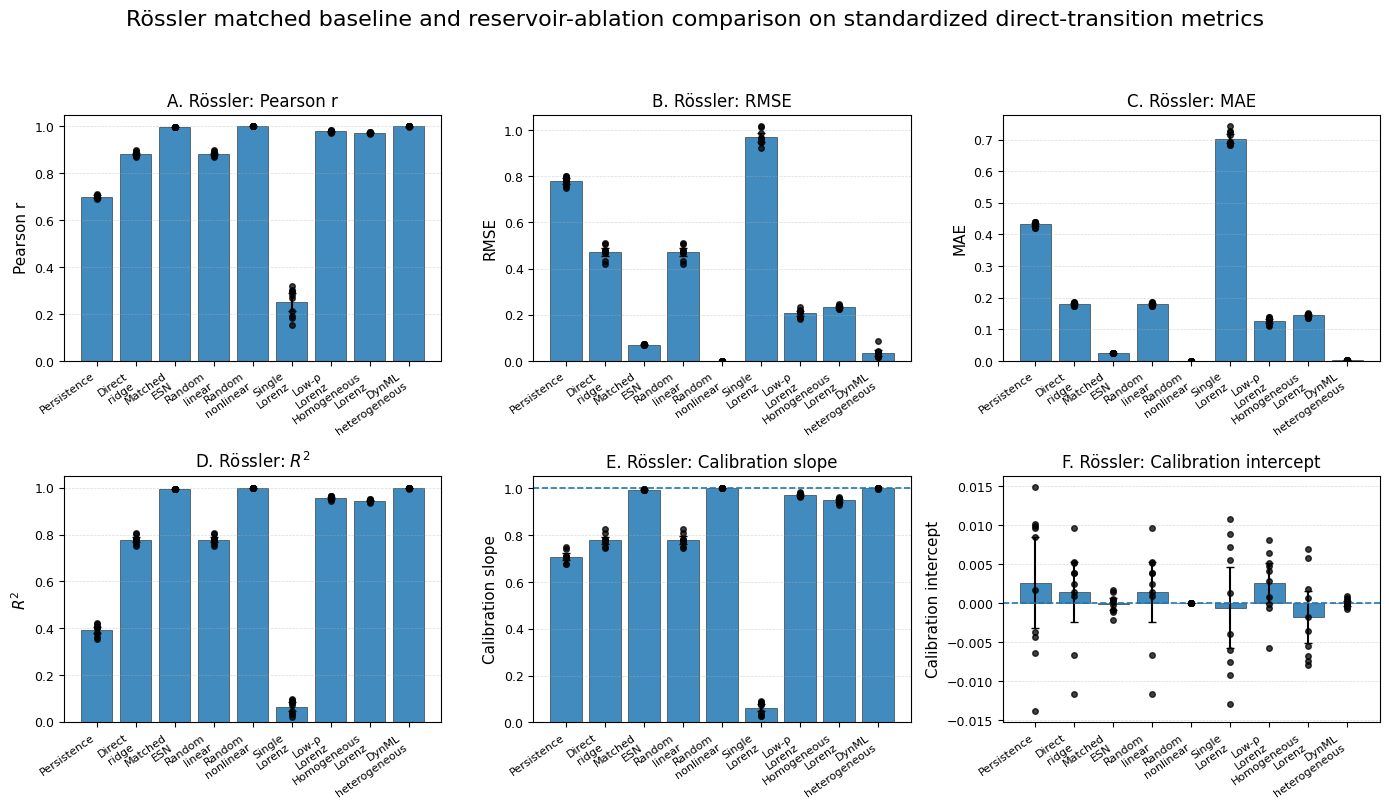


Saved Rössler all-metrics BD-style figure
-----------------------------------------
rossler_matched_baseline_all_metrics_BD_style.jpeg
rossler_matched_baseline_all_metrics_BD_style.pdf

Final Rössler table-ready test metrics, standardized output space
-----------------------------------------------------------------
Dataset                      Model  Feature dimension       Pearson r            RMSE             MAE              R2 Calibration slope Calibration intercept
Rössler                Persistence                  3 0.7002 ± 0.0050 0.7798 ± 0.0112 0.4320 ± 0.0048 0.3930 ± 0.0140   0.7077 ± 0.0144       0.0026 ± 0.0058
Rössler               Direct ridge                  3 0.8820 ± 0.0059 0.4718 ± 0.0174 0.1793 ± 0.0030 0.7779 ± 0.0105   0.7790 ± 0.0151       0.0014 ± 0.0038
Rössler                Matched ESN                450 0.9975 ± 0.0001 0.0713 ± 0.0005 0.0252 ± 0.0003 0.9949 ± 0.0002   0.9944 ± 0.0008      -0.0001 ± 0.0007
Rössler     Random linear features               

In [1]:
# ============================================================
# RÖSSLER-ONLY matched baseline and reservoir-ablation figure
# 2 rows x 3 columns layout
#
# Loads saved BD-style Rössler metrics CSV only.
# Does NOT rerun any models.
#
# Expected input file:
#   rossler_matched_ablation_BD_style_by_seed.csv
#
# Output:
#   rossler_matched_baseline_all_metrics_BD_style.jpeg
#   rossler_matched_baseline_all_metrics_BD_style.pdf
#   rossler_matched_baseline_summary_BD_style.csv
#   rossler_matched_baseline_table_ready_BD_style.csv
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# INPUT FILE
# ============================================================

ROSSLER_METRICS_FILE = Path(
    "rossler_matched_ablation_BD_style_by_seed.csv"
)

if not ROSSLER_METRICS_FILE.exists():
    raise FileNotFoundError(f"Could not find {ROSSLER_METRICS_FILE}")


# ============================================================
# OUTPUT FILES
# ============================================================

FIGURE_JPEG = "rossler_matched_baseline_all_metrics_BD_style.jpeg"
FIGURE_PDF = "rossler_matched_baseline_all_metrics_BD_style.pdf"
SUMMARY_TABLE_FILE = "rossler_matched_baseline_summary_BD_style.csv"
TABLE_READY_FILE = "rossler_matched_baseline_table_ready_BD_style.csv"


# ============================================================
# LOAD DATA
# ============================================================

metrics_df = pd.read_csv(ROSSLER_METRICS_FILE)

# Keep test split only
metrics_df = metrics_df[metrics_df["split"] == "test"].copy()


# ============================================================
# MODEL ORDER AND LABELS
# ============================================================

model_order = [
    "Persistence",
    "Direct ridge",
    "Matched ESN",
    "Random linear features",
    "Random nonlinear features",
    "Single Lorenz",
    "Low-rho non-chaotic Lorenz",
    "Homogeneous chaotic Lorenz",
    "DynML heterogeneous Lorenz"
]

label_map = {
    "Persistence": "Persistence",
    "Direct ridge": "Direct\nridge",
    "Matched ESN": "Matched\nESN",
    "Random linear features": "Random\nlinear",
    "Random nonlinear features": "Random\nnonlinear",
    "Single Lorenz": "Single\nLorenz",
    "Low-rho non-chaotic Lorenz": "Low-ρ\nLorenz",
    "Homogeneous chaotic Lorenz": "Homogeneous\nLorenz",
    "DynML heterogeneous Lorenz": "DynML\nheterogeneous"
}

metrics_df["model"] = pd.Categorical(
    metrics_df["model"],
    categories=model_order,
    ordered=True
)

metrics_df = metrics_df.sort_values(["model", "seed_id"])


# ============================================================
# SUMMARY
# ============================================================

def summarize_metric_df(df):
    rows = []

    grouped = df.groupby(["model", "feature_dim"], observed=True)

    for (model, feature_dim), group in grouped:
        row = {
            "dataset": "Rössler",
            "model": model,
            "feature_dim": feature_dim,
            "n_seeds": group["seed_id"].nunique()
        }

        for metric in [
            "pearson_r",
            "rmse",
            "mae",
            "r2",
            "calibration_slope",
            "calibration_intercept"
        ]:
            values = group[metric].dropna().values
            n = len(values)

            mean = np.mean(values) if n > 0 else np.nan
            sd = np.std(values, ddof=1) if n > 1 else np.nan
            sem = sd / np.sqrt(n) if n > 1 else np.nan
            ci95 = 1.96 * sem if n > 1 else np.nan

            row[f"{metric}_mean"] = mean
            row[f"{metric}_sd"] = sd
            row[f"{metric}_ci95"] = ci95

        rows.append(row)

    summary = pd.DataFrame(rows)

    summary["model"] = pd.Categorical(
        summary["model"],
        categories=model_order,
        ordered=True
    )

    return summary.sort_values("model")


summary_df = summarize_metric_df(metrics_df)
summary_df.to_csv(SUMMARY_TABLE_FILE, index=False)


# ============================================================
# TABLE-READY CSV
# ============================================================

def format_mean_ci(mean, ci):
    if pd.isna(mean):
        return "NA"
    if pd.isna(ci):
        return f"{mean:.4f}"
    return f"{mean:.4f} ± {ci:.4f}"


table_rows = []

for _, row in summary_df.iterrows():
    table_rows.append({
        "Dataset": row["dataset"],
        "Model": row["model"],
        "Feature dimension": int(row["feature_dim"]),
        "Pearson r": format_mean_ci(
            row["pearson_r_mean"],
            row["pearson_r_ci95"]
        ),
        "RMSE": format_mean_ci(
            row["rmse_mean"],
            row["rmse_ci95"]
        ),
        "MAE": format_mean_ci(
            row["mae_mean"],
            row["mae_ci95"]
        ),
        "R2": format_mean_ci(
            row["r2_mean"],
            row["r2_ci95"]
        ),
        "Calibration slope": format_mean_ci(
            row["calibration_slope_mean"],
            row["calibration_slope_ci95"]
        ),
        "Calibration intercept": format_mean_ci(
            row["calibration_intercept_mean"],
            row["calibration_intercept_ci95"]
        )
    })

table_ready_df = pd.DataFrame(table_rows)
table_ready_df.to_csv(TABLE_READY_FILE, index=False)

print("Saved summary files")
print("-------------------")
print(SUMMARY_TABLE_FILE)
print(TABLE_READY_FILE)
print()
print(table_ready_df.to_string(index=False))


# ============================================================
# PLOTTING HELPERS
# ============================================================

metric_specs = [
    ("pearson_r", "Pearson r", "Pearson r"),
    ("rmse", "RMSE", "RMSE"),
    ("mae", "MAE", "MAE"),
    ("r2", r"$R^2$", r"$R^2$"),
    ("calibration_slope", "Calibration slope", "Calibration slope"),
    ("calibration_intercept", "Calibration intercept", "Calibration intercept")
]

panel_letters = list("ABCDEF")


def plot_metric_panel(ax, metric, ylabel, panel_label):
    plot_summary = summary_df.copy()
    plot_raw = metrics_df.copy()

    plot_summary = plot_summary.sort_values("model")

    models = plot_summary["model"].astype(str).tolist()
    labels = [label_map[m] for m in models]
    x = np.arange(len(models))

    means = plot_summary[f"{metric}_mean"].values
    cis = plot_summary[f"{metric}_ci95"].values

    ax.bar(
        x,
        means,
        yerr=cis,
        capsize=3,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.4
    )

    seed_x = []
    seed_values = []

    for i, model in enumerate(models):
        values = plot_raw[
            plot_raw["model"].astype(str) == model
        ][metric].values

        seed_x.extend([i] * len(values))
        seed_values.extend(values)

    ax.scatter(
        seed_x,
        seed_values,
        color="black",
        s=16,
        alpha=0.75,
        zorder=3
    )

    ax.set_title(panel_label, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.45)

    if metric == "calibration_slope":
        ax.axhline(1.0, linestyle="--", linewidth=1.2)
    elif metric == "calibration_intercept":
        ax.axhline(0.0, linestyle="--", linewidth=1.2)

    if metric in ["pearson_r", "r2"]:
        ymin = min(0.0, np.nanmin(means - np.nan_to_num(cis, nan=0.0)) - 0.05)
        ymax = min(1.05, np.nanmax(means + np.nan_to_num(cis, nan=0.0)) + 0.05)
        ax.set_ylim(ymin, ymax)


# ============================================================
# MAKE 2 x 3 RÖSSLER FIGURE
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8.2))
axes = axes.flatten()

panel_plan = [
    ("pearson_r", "Pearson r"),
    ("rmse", "RMSE"),
    ("mae", "MAE"),
    ("r2", r"$R^2$"),
    ("calibration_slope", "Calibration slope"),
    ("calibration_intercept", "Calibration intercept")
]

metric_lookup = {
    metric: ylabel
    for metric, _, ylabel in metric_specs
}

for i, (metric, short_label) in enumerate(panel_plan):
    ylabel = metric_lookup[metric]
    panel_label = f"{panel_letters[i]}. Rössler: {short_label}"

    plot_metric_panel(
        ax=axes[i],
        metric=metric,
        ylabel=ylabel,
        panel_label=panel_label
    )

plt.suptitle(
    "Rössler matched baseline and reservoir-ablation comparison on standardized direct-transition metrics",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig(FIGURE_JPEG, dpi=650, bbox_inches="tight")
plt.savefig(FIGURE_PDF, bbox_inches="tight")
plt.show()

print()
print("Saved Rössler all-metrics BD-style figure")
print("-----------------------------------------")
print(FIGURE_JPEG)
print(FIGURE_PDF)

print()
print("Final Rössler table-ready test metrics, standardized output space")
print("-----------------------------------------------------------------")
print(table_ready_df.to_string(index=False))